<a href="https://colab.research.google.com/github/mzaib1012/Automated-Wire-Harness-Validation-Pipeline/blob/main/notebooks/wire_harness_validation_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🔌 System Interconnect Netlist baseline generated and stored.

🚨 INTERCONNECT DESIGN RULE CHECK (DRC) PIPELINE COMPLIANCE REPORT
  • Total Signal Interconnect Traces Checked : 7
  • Total Design Violations Isolated         : 4
❌ [CRITICAL CODE RED] Net: NET_PWR_24V | Type: Ampacity Violation
   ↳ Detail: AWG 28 wire overstressed! Expected load 3.2A exceeds safely rated threshold (1.4A)

❌ [CRITICAL CODE RED] Net: NET_CAN_H | Type: Pin Mismatch
   ↳ Detail: Signal NET_CAN_H maps to non-standard hardware endpoint pin J3-P9

⚠️  [DESIGN WARNING]    Net: GLOBAL_GND_PLANE | Type: Ground Loop Risk
   ↳ Detail: Common ground loop return breach detected on Power_Module! Analog and Digital planes intersect layout.

⚠️  [DESIGN WARNING]    Net: GLOBAL_GND_PLANE | Type: Ground Loop Risk
   ↳ Detail: Common ground loop return breach detected on Main_MCU! Analog and Digital planes intersect layout.



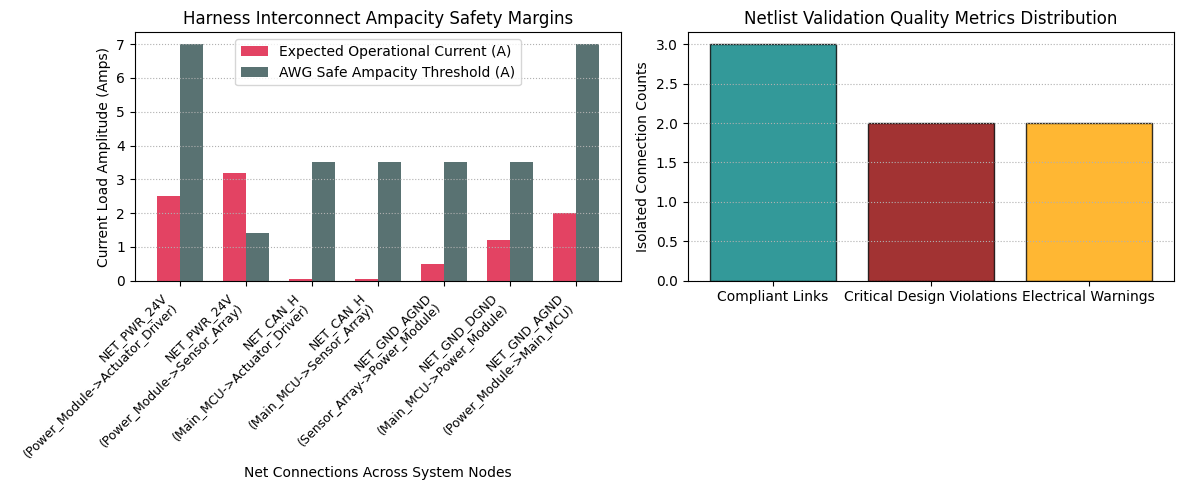

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Programmatically Generate a Complex Multi-Board Harness Netlist ---
# This simulates a raw system netlist exported from CAD tools (like KiCad, Altium, or Mentor Graphics)
harness_netlist_data = {
    'Net_ID': ['NET_PWR_24V', 'NET_PWR_24V', 'NET_CAN_H', 'NET_CAN_H', 'NET_GND_AGND', 'NET_GND_DGND', 'NET_GND_AGND'],
    'Source_Board': ['Power_Module', 'Power_Module', 'Main_MCU', 'Main_MCU', 'Sensor_Array', 'Main_MCU', 'Power_Module'],
    'Source_Pin': ['J1-P1', 'J1-P1', 'J2-P3', 'J2-P3', 'J3-P5', 'J2-P2', 'J1-P2'],
    'Destination_Board': ['Actuator_Driver', 'Sensor_Array', 'Actuator_Driver', 'Sensor_Array', 'Power_Module', 'Power_Module', 'Main_MCU'],
    'Destination_Pin': ['J4-P1', 'J3-P1', 'J4-P2', 'J3-P9', 'J1-P2', 'J1-P3', 'J2-P1'], # J3-P9 creates a naming mismatch alert, J1-P2/J2-P1 create a loop
    'Wire_Gauge_AWG': [22, 28, 24, 24, 24, 24, 22], # AWG 28 carrying high current will trigger a thermal violation flag
    'Max_Expected_Current_A': [2.5, 3.2, 0.05, 0.05, 0.5, 1.2, 2.0]
}

df_netlist = pd.DataFrame(harness_netlist_data)
df_netlist.to_csv('system_harness_netlist.csv', index=False)
print("🔌 System Interconnect Netlist baseline generated and stored.\n")

# --- 2. Automated Electrical Linting & Compliance Audit Engine ---
def run_harness_electrical_audit(netlist_path):
    df = pd.read_csv(netlist_path)

    violations_log = []
    audited_connections = 0

    # Standard engineering reference metrics mapping AWG size to conservative current capacities
    # Max continuous current ratings for chassis wiring at ambient temperature thresholds
    awg_capacity_limits = {20: 11.0, 22: 7.0, 24: 3.5, 26: 2.2, 28: 1.4}

    # Tracking sets to isolate structural grounding layouts
    agnd_nodes = set()
    dgnd_nodes = set()

    for idx, row in df.iterrows():
        audited_connections += 1
        net = row['Net_ID']
        src = f"{row['Source_Board']}({row['Source_Pin']})"
        dest = f"{row['Destination_Board']}({row['Destination_Pin']})"
        awg = row['Wire_Gauge_AWG']
        current = row['Max_Expected_Current_A']

        # Rule Check A: Pinout/Signal Mismatch Identification
        # Validates if differential signals or naming structures match across board endpoints
        if "CAN_H" in net and not row['Destination_Pin'].endswith(('P2', 'H')):
            violations_log.append({
                'Net': net, 'Type': 'Pin Mismatch', 'Severity': 'Critical',
                'Desc': f"Signal {net} maps to non-standard hardware endpoint pin {row['Destination_Pin']}"
            })

        # Rule Check B: Wire-Gauge Ampacity Thermal Overload Profile
        limit = awg_capacity_limits.get(awg, 1.0)
        if current > limit:
            violations_log.append({
                'Net': net, 'Type': 'Ampacity Violation', 'Severity': 'Critical',
                'Desc': f"AWG {awg} wire overstressed! Expected load {current}A exceeds safely rated threshold ({limit}A)"
            })

        # Rule Check C: Cross-Chassis Ground Loop Dependency Mapping
        # Track if mixed structural ground tracks link back to conflicting reference planes
        if "AGND" in net:
            agnd_nodes.add(row['Source_Board'])
            agnd_nodes.add(row['Destination_Board'])
        if "DGND" in net:
            dgnd_nodes.add(row['Source_Board'])
            dgnd_nodes.add(row['Destination_Board'])

    # Evaluate ground track overlaps to determine isolation breaches
    ground_loop_overlap = agnd_nodes.intersection(dgnd_nodes)
    for board in ground_loop_overlap:
        violations_log.append({
            'Net': 'GLOBAL_GND_PLANE', 'Type': 'Ground Loop Risk', 'Severity': 'Warning',
            'Desc': f"Common ground loop return breach detected on {board}! Analog and Digital planes intersect layout."
        })

    return df, pd.DataFrame(violations_log), audited_connections

# --- 3. Execute Verification Loop ---
df_harness, df_violations, total_traces = run_harness_electrical_audit('system_harness_netlist.csv')

print("="*80)
print("🚨 INTERCONNECT DESIGN RULE CHECK (DRC) PIPELINE COMPLIANCE REPORT")
print("="*80)
print(f"  • Total Signal Interconnect Traces Checked : {total_traces}")
print(f"  • Total Design Violations Isolated         : {len(df_violations)}")
print("="*80)

# Sort and print individual hardware red flags
critical_count = 0
warning_count = 0

for idx, row in df_violations.iterrows():
    if row['Severity'] == 'Critical':
        print(f"❌ [CRITICAL CODE RED] Net: {row['Net']} | Type: {row['Type']}\n   ↳ Detail: {row['Desc']}\n")
        critical_count += 1
    else:
        print(f"⚠️  [DESIGN WARNING]    Net: {row['Net']} | Type: {row['Type']}\n   ↳ Detail: {row['Desc']}\n")
        warning_count += 1
print("="*80)

# --- 4. Portfolio Metric Visualizations ---
plt.figure(figsize=(12, 5))

# Plot 1: Electrical Margin Ampacity Audit Profiles
plt.subplot(1, 2, 1)
awg_capacity_limits = {20: 11.0, 22: 7.0, 24: 3.5, 26: 2.2, 28: 1.4}
trace_labels = []
current_loads = []
safety_thresholds = []

for idx, row in df_harness.iterrows():
    trace_labels.append(f"{row['Net_ID']}\n({row['Source_Board']}->{row['Destination_Board']})")
    current_loads.append(row['Max_Expected_Current_A'])
    safety_thresholds.append(awg_capacity_limits.get(row['Wire_Gauge_AWG'], 1.0))

x = np.arange(len(trace_labels))
width = 0.35

plt.bar(x - width/2, current_loads, width, label='Expected Operational Current (A)', color='crimson', alpha=0.8)
plt.bar(x + width/2, safety_thresholds, width, label='AWG Safe Ampacity Threshold (A)', color='darkslategray', alpha=0.8)
plt.title('Harness Interconnect Ampacity Safety Margins')
plt.xlabel('Net Connections Across System Nodes')
plt.ylabel('Current Load Amplitude (Amps)')
plt.xticks(x, trace_labels, rotation=45, ha='right', fontsize=9)
plt.grid(axis='y', linestyle=':')
plt.legend()

# Plot 2: Total Pipeline Severity Assessment Matrix
plt.subplot(1, 2, 2)
categories = ['Compliant Links', 'Critical Design Violations', 'Electrical Warnings']
counts = [total_traces - critical_count - warning_count, critical_count, warning_count]
colors = ['teal', 'darkred', 'orange']

plt.bar(categories, counts, color=colors, edgecolor='black', alpha=0.8)
plt.title('Netlist Validation Quality Metrics Distribution')
plt.ylabel('Isolated Connection Counts')
plt.grid(axis='y', linestyle=':')

plt.tight_layout()
plt.savefig('wire_harness_validation_report.png', dpi=300)
plt.show()